# Resolution Alignment & TF-IDF Semantic Inspection

This interactive notebook lets you inspect how **TF-IDF semantic similarity** and **Needleman-Wunsch sequence alignment** perform on random and target session dates.

### Goals:
1. Inspect $N \times M$ similarity matrices (cosine similarity between enriched abstracts and flat transcriptions).
2. Observe the Needleman-Wunsch alignment trace through session resolutions.
3. View side-by-side matches with shared entity hits and score breakdowns.
4. Test random dates on pure local CPU ($0.00 cost, <1 second execution per date).

In [24]:
import sys
import importlib
from pathlib import Path
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Ensure repo root is on python path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import build_alignment_new
importlib.reload(build_alignment_new)

from data_io import resolve, load
from alignment_embeddings import AlignmentEmbedder
from build_alignment_new import (
    load_data,
    period_from_date,
    select_flat_candidates,
    calculate_idf_weights,
    paragraph_mapping_annotation_files,
    build_paragraph_to_resolution_map,
    build_overlap_lookups,
    build_date_to_session_map,
    align_session,
    align_session_milestone_tiered,
    stitch_flat_session_candidates,
    sort_key_res_id,
    resolve_shared_entities,
    resolve_enriched_entities,
    candidate_text,
    enriched_text,
    enriched_volgnr,
)

# Resolve the canonical frozen corpus through the manifest for traceability.
RESOLUTIONS_MANIFEST_PATH = resolve("resolutions_flat")
print(f"✓ Loaded alignment modules from {ROOT}")
print(f"✓ Manifest resolutions source: {RESOLUTIONS_MANIFEST_PATH}")

✓ Loaded alignment modules from /Users/rikhoekstra/develop/republic_ner_matching
✓ Manifest resolutions source: /Volumes/2tb disk/datasets/republic/resolutions/resolutions_flat.parquet


## 1. Load Window-Confined Data
Loads the enriched 1626–1630 resolutions, the window-pruned flat resolutions (~11.7k rows), canonical entity registries, and pre-computed Excel overlap matrices.

In [25]:
enriched_all, res_df, places_df, orgs_df, loc_names, per_names, org_names, persons_df = load_data()
res_df["date_period"] = pd.PeriodIndex(res_df["date_str"], freq="D")

# 1. Normalize and merge the Excel overlap data
if 'naam' in orgs_df.columns and 'name' not in orgs_df.columns:
    orgs_df = orgs_df.rename(columns={'naam': 'name'})
if 'naam' in places_df.columns and 'name' not in places_df.columns:
    places_df = places_df.rename(columns={'naam': 'name'})
if not persons_df.empty and 'naam' in persons_df.columns and 'name' not in persons_df.columns:
    persons_df = persons_df.rename(columns={'naam': 'name'})

overlap_frames = [
    places_df[["volgnr", "paragraph_id", "name"]],
    orgs_df[["volgnr", "paragraph_id", "name"]],
]
if not persons_df.empty:
    overlap_frames.append(persons_df[["volgnr", "paragraph_id", "name"]])

all_overlaps = pd.concat(overlap_frames, ignore_index=True)
idf_weights = calculate_idf_weights(all_overlaps)

# 2. Build paragraph to resolution id map from annotations
paragraph_ids = {
    str(paragraph_id).strip()
    for paragraph_id in all_overlaps["paragraph_id"].dropna().astype(str)
    if str(paragraph_id).strip()
}
paragraph_to_resolution = build_paragraph_to_resolution_map(
    paragraph_mapping_annotation_files(),
    paragraph_ids,
)

# 3. Build overlap lookups
(
    place_lookup,
    org_lookup,
    person_lookup,
    overlap_lookup,
) = build_overlap_lookups(places_df, orgs_df, paragraph_to_resolution, persons_df=persons_df if not persons_df.empty else None)

# 4. Map dates to session IDs based on overlapping entities
date_to_session_map = build_date_to_session_map(places_df, orgs_df, paragraph_to_resolution)

# Group enriched resolutions by date
enriched_by_date = {}
for enriched in enriched_all:
    date_raw = str(enriched.get("date", ""))[:10]
    enriched["date_str"] = date_raw if len(date_raw) == 10 else None
    resolved = resolve_enriched_entities(enriched, loc_names, per_names, org_names)
    enriched["entity_set"] = set(resolved["places"] + resolved["orgs"] + resolved.get("persons", []))
    if enriched["date_str"]:
        enriched_by_date.setdefault(enriched["date_str"], []).append(enriched)

print(f"✓ Ready: {len(enriched_by_date)} distinct dates available for inspection.")

Loading data files...
✓ Confined flat resolutions to enriched window [1625-12-02 .. 1630-06-13]: 11754 of 692156 retained
Loading overlap matrices (Excel)...
✓ Loaded 19134 enriched resolutions
✓ Loaded 11754 flat resolutions
✓ Loaded 11848 place overlaps, 1651 org overlaps, 8665 person overlaps
Loading cached paragraph map from paragraph_to_resolution.parquet...
✓ Loaded 8315 paragraph_ids from cache
✓ Ready: 1594 distinct dates available for inspection.


## 2. Initialize the TF-IDF Embedder
Uses sublinear character (3–5 n-grams) and word (1–2 n-grams) TF-IDF vectorization to bridge early-modern spelling variations.

In [26]:
embedder = AlignmentEmbedder(backend="tfidf")
print("✓ Initialized TF-IDF embedder")

✓ Initialized TF-IDF embedder


## 3. Date Alignment & Inspection Function

In [27]:
def inspect_date(
    target_date: str,
    anchor_threshold: float = 2.0,
    plot_heatmap: bool = True,
):
    """Inspect tiered milestone alignment, stitched folio continuations, and TF-IDF matrix for one date."""
    day_enriched = enriched_by_date.get(target_date)
    if not day_enriched:
        print(f"No enriched resolutions found for date {target_date}")
        return

    day_enriched = sorted(day_enriched, key=lambda x: int(x.get("resolution_index", 0)))
    enriched_period = period_from_date(target_date)
    if enriched_period is None:
        print(f"Invalid date: {target_date!r}")
        return

    day_flat, pool_label = select_flat_candidates(
        res_df,
        target_date,
        enriched_period,
        date_to_session_map,
        date_window_days=0,
        session_first=True,
    )

    if day_flat.empty:
        print("No flat candidate resolutions found in pool.")
        return

    raw_flat_count = len(day_flat)
    day_flat = stitch_flat_session_candidates(day_flat)
    stitched_flat_count = len(day_flat)

    n, m = len(day_enriched), len(day_flat)
    print(f"=== Date: {target_date} ({pool_label}) ===")
    print(f"Enriched resolutions: {n} | Flat candidates: {raw_flat_count} (stitched to {stitched_flat_count} units)")

    day_enriched_ids = [enriched_volgnr(e) or "" for e in day_enriched]
    day_flat_ids = day_flat["id"].astype(str).tolist()
    flat_id_map = {str(r["id"]): r.get("stitched_ids", [str(r["id"])]) for _, r in day_flat.iterrows()}

    enr_texts = [enriched_text(e) for e in day_enriched]
    flat_texts = [candidate_text(f) for _, f in day_flat.iterrows()]
    sim_matrix = embedder.compute_similarity_matrix(enr_texts, flat_texts)

    tiered_matches = align_session_milestone_tiered(
        enriched_ids=day_enriched_ids,
        flat_ids=day_flat_ids,
        overlap_lookup=overlap_lookup,
        idf_weights=idf_weights,
        anchor_threshold=anchor_threshold,
        similarity_matrix=sim_matrix,
        allow_multi_match=True,
        flat_id_map=flat_id_map,
    )

    if plot_heatmap and n > 0 and m > 0:
        _, ax = plt.subplots(figsize=(max(7, m * 0.8), max(4, n * 0.5)))
        vmax = max(0.5, float(sim_matrix.max()) if sim_matrix.size else 1.0)
        im = ax.imshow(sim_matrix, cmap="YlGnBu", aspect="auto", vmin=0.0, vmax=vmax)

        for e_idx, f_idx, tier_label, score in tiered_matches:
            if e_idx is None or f_idx is None:
                continue
            if tier_label == "tier1_anchor":
                ax.plot(f_idx, e_idx, marker="*", markersize=14, color="gold", markeredgecolor="darkgreen", markeredgewidth=1.5, label="Tier 1 Anchor" if "Tier 1 Anchor" not in ax.get_legend_handles_labels()[1] else "")
            elif tier_label.startswith("tier2"):
                ax.plot(f_idx, e_idx, marker="o", markersize=9, color="cyan", markeredgecolor="blue", markeredgewidth=1.5, label="Tier 2 Interpolated" if "Tier 2 Interpolated" not in ax.get_legend_handles_labels()[1] else "")
            else:
                ax.plot(f_idx, e_idx, marker="s", markersize=8, color="orange", markeredgecolor="red", markeredgewidth=1.5, label="Tier 3 Review" if "Tier 3 Review" not in ax.get_legend_handles_labels()[1] else "")

        ax.set_xticks(range(m))
        ax.set_xticklabels([f"F{i + 1}" for i in range(m)], fontsize=9)
        ax.set_yticks(range(n))
        ax.set_yticklabels([f"E{i + 1}" for i in range(n)], fontsize=9)
        ax.set_xlabel("Flat Resolutions (HTR units)", fontweight="bold")
        ax.set_ylabel("Enriched Resolutions (Abstracts)", fontweight="bold")
        ax.set_title(f"Tiered Milestone Alignment Matrix ({target_date})\n★ = Tier 1 Anchor, ● = Tier 2 Interpolated, ■ = Tier 3 Review", fontsize=11)
        ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0), borderaxespad=0.0)
        plt.colorbar(im, ax=ax, label="Cosine Similarity", fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    tier_colors = {
        "tier1_anchor": ("#d4edda", "#155724", "Tier 1 (Anchor Milestone)"),
        "tier2_merged_page": ("#d1ecf1", "#0c5460", "Tier 2 (Merged Page)"),
        "tier2_interpolated": ("#d1ecf1", "#0c5460", "Tier 2 (Interpolated)"),
        "tier2_adjacent": ("#d1ecf1", "#0c5460", "Tier 2 (Adjacent)"),
        "tier3_head_template": ("#fff3cd", "#856404", "Tier 3 (Opening Template)"),
        "tier3_tail": ("#fff3cd", "#856404", "Tier 3 (Tail Review)"),
        "tier3_unanchored": ("#f8d7da", "#721c24", "Tier 3 (Unanchored)"),
    }

    rows_html = []
    for e_idx, f_idx, tier_label, score in tiered_matches:
        if e_idx is None or f_idx is None:
            continue

        e_rec = day_enriched[e_idx]
        f_rec = day_flat.iloc[f_idx]
        e_id = enriched_volgnr(e_rec) or ""
        f_id = str(f_rec["id"])
        info = resolve_shared_entities(
            e_rec,
            f_rec,
            (e_id, f_id),
            place_lookup,
            org_lookup,
            loc_names,
            per_names,
            org_names,
            date_window_days=0,
        )
        overlap_score = sum(idf_weights.get(entity, 1.0) for entity in info["shared_entities"])
        sem_sim = float(sim_matrix[e_idx, f_idx])

        e_text = enriched_text(e_rec)
        f_text = candidate_text(f_rec)
        bg_col, text_col, badge_title = tier_colors.get(tier_label, ("#eee", "#333", tier_label))
        shared_str = ", ".join(info["shared_entities"]) if info["shared_entities"] else "<i>(none)</i>"
        
        stitched_note = f"<br><small style='color: #0066cc;'>[Stitched: {len(f_rec.get('stitched_ids', []))} parts]</small>" if len(f_rec.get('stitched_ids', [])) > 1 else ""

        rows_html.append(f"""
        <tr style='border-bottom: 1px solid #ddd;'>
            <td style='padding: 8px; font-weight: bold;'>E{e_idx + 1} &harr; F{f_idx + 1}<br><small style='color: #666;'>{e_id}<br>{f_id}</small>{stitched_note}</td>
            <td style='padding: 8px; font-size: 0.9em;'>{e_text[:220]}{'...' if len(e_text) > 220 else ''}</td>
            <td style='padding: 8px; font-size: 0.9em;'>{f_text[:220]}{'...' if len(f_text) > 220 else ''}</td>
            <td style='padding: 8px; font-size: 0.85em;'>{shared_str}</td>
            <td style='padding: 8px; text-align: center;'><b>{sem_sim:.3f}</b></td>
            <td style='padding: 8px; text-align: center;'>{overlap_score:.2f}</td>
            <td style='padding: 8px; text-align: center;'><span style='background: {bg_col}; color: {text_col}; padding: 3px 6px; border-radius: 4px; font-size: 0.85em; font-weight: bold;'>{badge_title}</span></td>
        </tr>
        """)

    if rows_html:
        display(HTML(f"""
        <table style='width: 100%; border-collapse: collapse; margin-top: 10px; font-family: sans-serif;'>
            <thead><tr style='background: #f1f3f5; text-align: left; border-bottom: 2px solid #ccc;'>
                <th style='padding: 8px;'>Pair</th><th style='padding: 8px; width: 32%;'>Enriched Summary</th>
                <th style='padding: 8px; width: 32%;'>Flat Transcription</th><th style='padding: 8px;'>Shared Entities</th>
                <th style='padding: 8px;'>TF-IDF Sim</th><th style='padding: 8px;'>Overlap Score</th><th style='padding: 8px;'>Confidence Tier</th>
            </tr></thead><tbody>{''.join(rows_html)}</tbody>
        </table>
        """))

## 4. Test on a Random Date
Run this cell multiple times to inspect random dates across the 1626–1630 corpus.

Selected random date: 1628-11-23
=== Date: 1628-11-23 (session(1)) ===
Enriched resolutions: 9 | Flat candidates: 5 (stitched to 5 units)


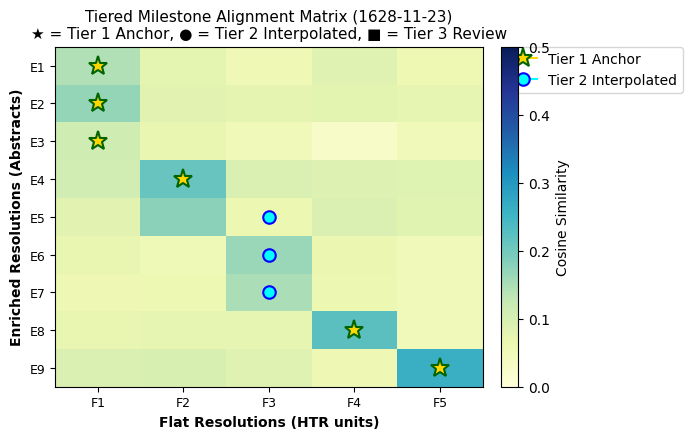

Pair,Enriched Summary,Flat Transcription,Shared Entities,TF-IDF Sim,Overlap Score,Confidence Tier
E1 ↔ F11628-11-23_0session-3187-num-273-resolution-1,De Gedeputeerde Staten van Groningen berichten d.d. Groningen 8/18 nov. over de op 13/23 nov. aan hen gestuurde brief van Tilly. De waterkering is gemaakt ter bescherming van de provincie tegen strooptochten van de vija...,Ontfangen een missive vande Gedeputeerden Staten van Stadt Groeningen ende Ommelanden geschreven binnen derselvers Stede den 7een. deses houdende bericht opde missive vanden Grave van Tilly den ee daer te vooren haer E. ...,(none),0.143,0.00,Tier 1 (Anchor Milestone)
E2 ↔ F11628-11-23_1session-3187-num-273-resolution-1,"Z.Exc. brengt twee brieven d.d. 11 nov. ter sprake waarin Pieter Schryver, inwoner van Graft in Waterland, meldt een manier te hebben bedacht om de havens van Vlaanderen en het Scheurtje bij Duinkerke af te sluiten. H...",Ontfangen een missive vande Gedeputeerden Staten van Stadt Groeningen ende Ommelanden geschreven binnen derselvers Stede den 7een. deses houdende bericht opde missive vanden Grave van Tilly den ee daer te vooren haer E. ...,Duinkerke,0.169,4.94,Tier 1 (Anchor Milestone)
E3 ↔ F11628-11-23_2session-3187-num-273-resolution-1,"Om te achterhalen waarom kapitein Douglas zijn voorgestelde uitvindingen niet in de praktijk brengt, waarvan aantekeningen zijn gemaakt in het secreet register, laten HHM hem zo spoedig mogelijk voor hen verschijnen. D...",Ontfangen een missive vande Gedeputeerden Staten van Stadt Groeningen ende Ommelanden geschreven binnen derselvers Stede den 7een. deses houdende bericht opde missive vanden Grave van Tilly den ee daer te vooren haer E. ...,(none),0.112,0.00,Tier 1 (Anchor Milestone)
E4 ↔ F21628-11-23_3session-3187-num-273-resolution-2,HHM verzoeken de RvS conform het door hem op 20 nov. opgestelde advies over de brief van de hertog van Neuburg aangaande de overlast van staatse soldaten aan de hertog te schrijven. Wanneer die van het garnizoen van Dü...,Is gelesen t'advis des Raets van State geformeert den xxen. deses opden brieff van hertooch van Nieuwurch clagende over de foules van dese landen Crychsvolck in syne neutrale landen. Waerop gedelibereert synde hebben hae...,Düsseldorf,0.209,6.79,Tier 1 (Anchor Milestone)
E5 ↔ F31628-11-23_4session-3187-num-273-resolution-3,"HHM lezen het rekest van Jeremias Clopper, koopman te Amsterdam. De Admiraliteit te Rotterdam heeft hem veroordeeld omdat hij enkele goederen voor konvooi heeft verzwegen. HHM verlenen de suppliant mandement van revi...","Opt versouck van Laurens de Maerschalck gewesen rechter in Ambong Is hem tottet maecken van een cleedt toegevoucht de somme van hondert guldens, boven de driehondert guldens die hem voordesen tot betalinge van syne montc...",(none),0.064,0.00,Tier 2 (Interpolated)
E6 ↔ F31628-11-23_5session-3187-num-273-resolution-3,"Op verzoek van Laurens de Maerschalck, voormalig rechter op Amboina, geven HHM hem 100 gld. voor het laten maken van kleding naast de hem eerder toegezegde 300 gld. per jaar voor de betaling van zijn proviand.","Opt versouck van Laurens de Maerschalck gewesen rechter in Ambong Is hem tottet maecken van een cleedt toegevoucht de somme van hondert guldens, boven de driehondert guldens die hem voordesen tot betalinge van syne montc...",(none),0.165,0.00,Tier 2 (Interpolated)
E7 ↔ F31628-11-23_6session-3187-num-273-resolution-3,"Daniel Pleum, als lanspassaat uitgevaren met de vloot van L'Hermyte, vraagt om betaling van zijn resterende gage à 199 pond 4 st. HHM geven het verzoek voor advies aan commies Verhaer.","Opt versouck van Laurens de Maerschalck gewesen rechter in Ambong Is hem tottet maecken van een cleedt toegevoucht de somme van hondert guldens, boven de driehondert guldens die hem voordesen tot betalinge van syne montc...",(none),0.149,0.00,Tier 2 (Interpolated)
E8 ↔ F41628-11-23_7session-3187-num-273-resolution-4,Vice-admiraal Quast verzoekt betaling van twintig maanden gage à 100 gld. per maand omda

In [28]:
# Filter to dates with at least 3 resolutions for meaningful sequence alignment
candidate_dates = [d for d, items in enriched_by_date.items() if len(items) >= 3]
random_date = random.choice(candidate_dates)

print(f"Selected random date: {random_date}")
inspect_date(random_date)

## 5. Sample 3 Random Dates Sequentially
Quickly inspect 3 different random dates in one go.

In [7]:
sample_dates = random.sample(candidate_dates, 3)
for d in sample_dates:
    inspect_date(d)
    print("\n" + "="*80 + "\n")

=== Date: 1628-10-21 (session(1)) ===
Enriched resolutions: 24 | Flat candidates: 2557


Pair,Enriched Summary,Flat Transcription,Shared Entities,TF-IDF Sim,Overlap Score,Kind
E2 ↔ F20521628-10-21_1session-3187-num-244-resolution-1,Essen en Noortwijck berichten conform de resolutie van 14 okt. de op 13 okt. ontvangen brief van de koning van Frankrijk en de retroacta over de zaak tussen diens op Oost-Indië handeldrijvende onderdanen en de VOC ...,"De Heer President heeft gerapporteert dat haer Ho:Mo: Ambassadeurs in Vrancryck opde recommandatie vande Coninginne moeder, hebben geschreven aen syn Excie., ende versocht dot de selve byde Ruiterie ende soldaten binnen ...","Oost-Indië, Frankrijk",0.145,8.74,places_only
E4 ↔ F20561628-10-21_3session-3187-num-244-resolution-2,"Naar aanleiding van de memorie van de heer Morisset, secretaris van voormalig ambassadeur D'Espesses, verlenen HHM hem en zijn dienaren en equipage gratis paspoort om door Brabant naar Frankrijk te mogen vertrekken.","Opde Memorie van Monsiour Marisset Secretanrs van geweesen Morisset pasport Ambassadeur d'Espesses, Is by desen geconsenteert ende geaccordeert gratis passeport voor hem synen, dienaer ende equipage om door Brabant nae V...",Brabant,0.214,4.09,places_only
E10 ↔ F20591628-10-21_9session-3187-num-244-resolution-5,Naar aanleiding van het verzoek van verschillende Amsterdamse kooplieden wier schepen en goederen door Engelsen in beslag zijn genomen laten HHM de griffier agent Carlaton verzoeken om ten gunste van hen aan Engelan...,Opt versouck van verscheyden Coopluiden tot Amsterdam wiens schepen schepen van dese landen ende goederen by d'Engelsen syn aengehaelt uyt oorsaecke dat sy nae In Engelt aengehaelt Vrancryck wilden seylen. Is nae voorgae...,"Engeland, Amsterdam",0.173,5.60,places_only
E12 ↔ F20601628-10-21_11session-3187-num-244-resolution-6,De aanwezige afgevaardigden van de Admiraliteit te Dokkum vragen of met goederen beladen Nederlandse schepen richting Oost-Friesland - en andere plaatsen waar keizerlijke troepen liggen - op de Wadden mogen worden vero...,"Ontfangen een missive van Borgermrs. ende Raden der Stede Hoorn geschreven aldaer den xvijen. deses, houdende onder anderen advis, dat sy niet en souder konner gedoogen dat Jan Symons Blauhulck syn commissie als vendumt ...","Oost-Friesland, Engeland, Frankrijk",0.101,10.21,places_only




=== Date: 1628-02-08 (session(1)) ===
Enriched resolutions: 13 | Flat candidates: 2557


Pair,Enriched Summary,Flat Transcription,Shared Entities,TF-IDF Sim,Overlap Score,Kind
E1 ↔ F2391628-02-08_0session-3187-num-36-resolution-1,"In een memorie vraagt Steven Groulart terugbetaling van de door hem sinds drie jaar voorgeschoten 62 gld. 16 st. aan port van brieven uit Algiers, Tunis, Venetië, Polen en de Sont. HHM depêcheren ordonnantie van dit...",Opte declaratie van Jan de Jonge burger van Hage van oncosten by hem gedaen int ouerbrengen van eenige brieuen van heeren haer Ho:Mo: gesanten in Sweeden en Poolen beloopen ter somme van xlvij. gul ny sts. Is goetgevonde...,Algiers,0.209,4.77,places_only
E3 ↔ F2421628-02-08_2session-3187-num-36-resolution-3,"De burgemeesters, schepenen en raden van Middelburg schrijven d.d. 25 jan. ten behoeve van Pieter Bisschop, Jacob Claessen Haiman en Adriaen van Hecke, kooplieden aldaar, of zij in Engeland geholpen kunnen worden met...","Ontfangen een missiue van Burgemrs Schepenen en Raden der Stadt Middelborch gedateert den 25e. January lestleden, in faueur van Pieter Bisschop, Jacob Claessen Haiman en adriaen van Hecke coopluyden aldaer geschreuen, te...","Engeland, Middelburg",0.290,8.21,places_only




=== Date: 1626-09-19 (same-day) ===
Enriched resolutions: 22 | Flat candidates: 0
No flat candidate resolutions found in pool.




## 6. Optional LLM Summary Comparison
This is a small, local-only experiment. It sends at most eight existing labeled pairs to Ollama, asks for structured event summaries of the flat texts, caches the results, and compares the generated summaries with the enriched summaries using the same TF-IDF embedder. It does not run unless the next cell is executed.

In [21]:
import json
import re
import urllib.request
from data_io import save_semi_structured

LLM_CACHE_PATH = ROOT / "output" / "llm_summary_experiment.jsonl"
LLM_MODEL = "llama3.2:latest"
LLM_MAX_PAIRS = 25


def ollama_summary(full_text: str, model: str = LLM_MODEL) -> dict:
    prompt = f"""You are analyzing a 17th-century Dutch Republic resolution.
Extract a compact factual event fingerprint from this HTR text.
Return JSON only with these keys: actors, places, organizations, subject, action, date.
Each value must be a short string; do not invent information. Use an empty string when unknown.

HTR TEXT:
{full_text[:1800]}
"""
    payload = json.dumps({
        "model": model,
        "prompt": prompt,
        "stream": False,
        "format": "json",
        "options": {"temperature": 0.0},
    }).encode("utf-8")
    request = urllib.request.Request(
        "http://localhost:11434/api/generate",
        data=payload,
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(request, timeout=45) as response:
        raw = json.loads(response.read().decode("utf-8")).get("response", "")
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if not match:
        raise ValueError("Ollama did not return a JSON object")
    parsed = json.loads(match.group(0))
    keys = ["actors", "places", "organizations", "subject", "action", "date"]
    return {key: str(parsed.get(key, "")) for key in keys}


def run_llm_summary_experiment(max_pairs: int = LLM_MAX_PAIRS, seed: int = 9673):
    labeled_path = ROOT / "output" / "ground_truth_labeled.json"
    if not labeled_path.exists():
        print(f"Missing labeled ground truth: {labeled_path}")
        return pd.DataFrame()

    try:
        with urllib.request.urlopen("http://localhost:11434/api/tags", timeout=3) as response:
            if response.status != 200:
                print("Ollama is not available; no calls made.")
                return pd.DataFrame()
    except Exception:
        print("Ollama is not available; no calls made.")
        return pd.DataFrame()

    records = json.loads(labeled_path.read_text(encoding="utf-8"))
    rng = random.Random(seed)
    selected = records.copy()
    rng.shuffle(selected)
    selected = selected[:max_pairs]
    cached = {}
    if LLM_CACHE_PATH.exists():
        cached = {
            row["pair_key"]: row
            for row in (json.loads(line) for line in LLM_CACHE_PATH.read_text(encoding="utf-8").splitlines() if line.strip())
        }

    enriched_by_id = {enriched_volgnr(item): item for item in enriched_all if enriched_volgnr(item)}
    output_rows = []
    for record in selected:
        pair_key = f"{record['enriched_id']}::{record['flat_id']}"
        if pair_key in cached:
            result = cached[pair_key]
        else:
            enriched_record = enriched_by_id.get(record["enriched_id"])
            flat_record = res_df[res_df["id"].astype(str) == str(record["flat_id"])]
            if enriched_record is None or flat_record.empty:
                continue
            try:
                fingerprint = ollama_summary(candidate_text(flat_record.iloc[0]))
            except Exception as error:
                print(f"Skipping {pair_key}: {error}")
                continue
            generated_text = " | ".join(f"{key}: {value}" for key, value in fingerprint.items() if value)
            enriched_summary = enriched_text(enriched_record)
            score = float(embedder.compute_similarity_matrix([enriched_summary], [generated_text])[0, 0])
            result = {
                "pair_key": pair_key,
                "enriched_id": record["enriched_id"],
                "flat_id": record["flat_id"],
                "verdict": record.get("verdict"),
                "tfidf_summary_score": score,
                "fingerprint": fingerprint,
            }
            cached[pair_key] = result
            save_semi_structured(
                list(cached.values()),
                out_path=LLM_CACHE_PATH,
                parent_sources=["resolutions_flat", "ground_truth_labeled"],
                description="Cached local LLM event fingerprints for labeled resolution alignment experiments.",
                script="notebooks/alignment_inspection.ipynb",
            )
        output_rows.append(result)

    result_df = pd.DataFrame(output_rows)
    if result_df.empty:
        print("No experiment rows were produced.")
        return result_df
    display(result_df[["enriched_id", "flat_id", "verdict", "tfidf_summary_score"]])
    print("Mean TF-IDF summary score by manual verdict:")
    display(result_df.groupby("verdict")["tfidf_summary_score"].agg(["count", "mean", "median"]))
    print(f"Cached LLM fingerprints: {LLM_CACHE_PATH}")
    return result_df

# Opt-in: this makes local Ollama calls and costs time, but no external API calls.
llm_experiment = run_llm_summary_experiment()

,enriched_id,flat_id,verdict,tfidf_summary_score
0,1626-10-06_2,session-3185-num-160-resolution-25,false_positive,0.076074
1,1628-11-06_7,session-3187-num-258-resolution-4,correct,0.048748
2,1629-09-08_9,session-3188-num-206-resolution-2,correct,0.087519
3,1627-08-08_0,session-3186-num-131-resolution-1,correct,0.135316
4,1628-03-28_8,session-3187-num-84-resolution-5,correct,0.093841
5,1630-02-20_11,session-3189-num-45-resolution-6,false_positive,0.027994
6,1629-05-05_9,session-3188-num-118-resolution-7,false_positive,0.129628
7,1629-01-13_0,session-3188-num-13-resolution-1,correct,0.109724
8,1627-02-16_2,session-3186-num-29-resolution-2,correct,0.094109
9,1626-08-06_9,session-3185-num-127-resolution-6,correct,0.147583


Mean TF-IDF summary score by manual verdict:


,count,mean,median
verdict,,,
correct,13,0.100584,0.109724
false_positive,12,0.073128,0.078048


Cached LLM fingerprints: /Users/rikhoekstra/develop/republic_ner_matching/output/llm_summary_experiment.jsonl
